# Lab 02 - Images, Frequencies, and Edges

**Topics:** image histograms, image resizing, frequency-domain filtering, and Canny edge detection  
**Suggested duration:** 90 minutes

## Learning outcomes

By the end of this lab, you should be able to:

1. compute and interpret grayscale and RGB histograms;
2. explain how interpolation affects image resizing;
3. construct low-pass and high-pass filters in the Fourier domain;
4. inspect the intermediate stages of the Canny detector; and
5. select parameters by connecting an algorithmic choice to its visual effect.

Work through the notebook in order. Every numbered question has a matching answer in the solutions notebook.

## 0. Setup - 5 minutes

Run the cell below. Images are represented as RGB NumPy arrays with values in **[0, 1]**. We use only NumPy, Matplotlib, Pillow, SciPy, and OpenCV.

shape: (512, 512, 3) dtype: float32 range: (0.0, 1.0)


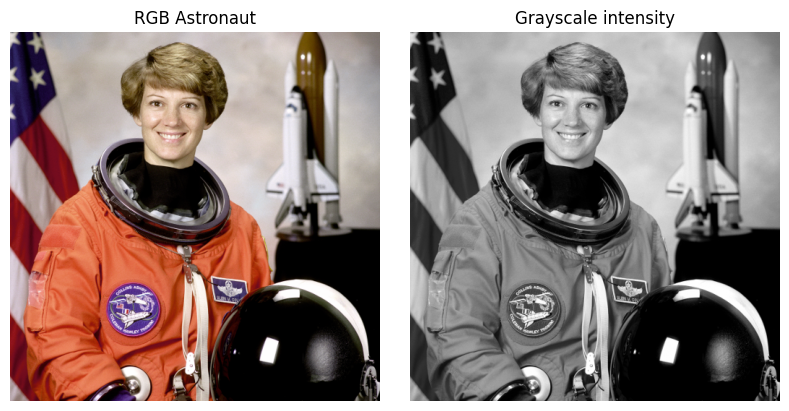

In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import ndimage
from skimage import data


def to_gray(rgb):
    # ITU-R BT.601 luma approximation
    return (
        0.299 * rgb[..., 0]
        + 0.587 * rgb[..., 1]
        + 0.114 * rgb[..., 2]
    )


def show_row(images, titles, cmaps=None, figsize=(16, 4)):
    cmaps = cmaps or [None] * len(images)

    fig, axes = plt.subplots(
        1,
        len(images),
        figsize=figsize,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.show()


# Built-in RGB test image from scikit-image
rgb = data.astronaut().astype(np.float32) / 255.0
gray = to_gray(rgb)

print(
    "shape:", rgb.shape,
    "dtype:", rgb.dtype,
    "range:", (float(rgb.min()), float(rgb.max())),
)

show_row(
    [rgb, gray],
    ["RGB Astronaut", "Grayscale intensity"],
    [None, "gray"],
    figsize=(8, 4),
)

## 1. Histograms - 15 minutes

A histogram counts how many pixels fall into each intensity interval. It discards spatial location, but reveals exposure, contrast, and color-channel distributions.

### Question 1.1

Compute a 256-bin normalized histogram for the grayscale image and for each RGB channel. Plot the grayscale histogram separately and the RGB curves together. Label both axes.

### Question 1.2

Report the grayscale mean, standard deviation, and the 5th/95th percentiles. What do these statistics and the histogram say about the image's brightness and contrast?

In [ ]:
bins = np.linspace(0.0, 1.0, 257)

gray_hist, _ = np.histogram(gray, bins=bins, density=True)
# One normalized (density) histogram per RGB channel, on the same bin edges.
rgb_hists = [np.histogram(rgb[..., c], bins=bins, density=True)[0] for c in range(3)]

centers = (bins[:-1] + bins[1:]) / 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(centers, gray_hist, color="black")
axes[0].set(title="Grayscale histogram", xlabel="Intensity", ylabel="Density")

for hist, color, label in zip(rgb_hists, "rgb", ["Red", "Green", "Blue"]):
    axes[1].plot(centers, hist, color=color, label=label)
axes[1].set(title="RGB channel histograms", xlabel="Channel value", ylabel="Density")
axes[1].legend()
plt.show()

stats = [gray.mean(), gray.std(), *np.percentile(gray, [5, 95])]
print("mean, std, p05, p95:", [round(float(s), 4) for s in stats])

# Supporting numbers for Question 1.2
print(f"grayscale median      = {float(np.median(gray)):.4f}")
print(f"pixels exactly 0.0    = {100 * float((gray == 0).mean()):.1f}%   (black background)")
print(f"pixels above 0.9      = {100 * float((gray > 0.9).mean()):.1f}%")
print(f"pixels at 1.0         = {100 * float((gray >= 0.999).mean()):.2f}%   (clipped highlights)")
for c, name in enumerate(["Red  ", "Green", "Blue "]):
    ch = rgb[..., c]
    print(f"{name} mean = {ch.mean():.4f}   std = {ch.std():.4f}   p95 = {np.percentile(ch, 95):.4f}")

#### Answer 1.2

**Measured statistics (grayscale):** mean = **0.4526**, std = **0.2946**, p05 = **0.0000**, p95 = **0.8498**, median = 0.5068.

**Brightness.** The mean sits almost exactly at mid-grey (0.45 on a [0, 1] scale), so the image is neither globally under- nor over-exposed. That single number is misleading on its own, though, because the histogram is clearly **bimodal**. Roughly 17.5% of all pixels fall in the darkest sixteenth of the range and 10.7% are *exactly* 0.0 — this is the black background behind the astronaut, not crushed shadow detail in the subject. The remaining pixels form a broad cluster across the mid and upper tones that peaks near 0.76 (the white spacesuit and the lit panel behind her). The mean lands near 0.45 simply because it averages these two populations.

**Contrast.** std = 0.2946 is large for a [0, 1] image, and the p05–p95 interval spans 0.85 of the full range, so the image already occupies nearly the whole dynamic range: global contrast is good and a contrast stretch would gain essentially nothing. p05 = 0.0000 is a direct consequence of the large pure-black background (>5% of pixels are 0), not a sign that the subject is clipped. At the bright end only 2.7% of pixels exceed 0.9 and just 0.09% reach 1.0, so the highlights approach saturation without being blown out — detail is retained in the white suit.

**Colour channels.** The channel means are ordered R (0.555) > G (0.415) > B (0.378) and the red curve is visibly shifted to the right of green and blue. The image is warm-toned: skin, the red stripes of the flag patch, and the warm lighting all push the red channel up. All three channels share the same spike at 0, which is the common black background — a reminder that the histogram encodes *how many* pixels have each value and nothing at all about *where* they are.

## 2. Image resizing - 20 minutes

Downsampling removes samples; upsampling estimates new samples. Nearest-neighbor copies a nearby value, while bilinear and bicubic interpolation blend neighborhoods.

### Question 2.1

Resize example image from its original size to **25%** in each dimension, then restore it to the original size using nearest-neighbor, bilinear, and bicubic interpolation. Display the original and three reconstructions at equal display size.

### Question 2.2

Compute the mean-squared error (MSE) and peak signal-to-noise ratio (PSNR) of each reconstruction. Which interpolation gives the best numerical score? Which artifacts do you observe around the hat, feathers, and eyes?

In [ ]:
def resize_rgb(rgb, size_wh, resample):
    u8 = np.clip(rgb * 255, 0, 255).astype(np.uint8)
    return np.asarray(Image.fromarray(u8).resize(size_wh, resample=resample), dtype=np.float32) / 255.0

def mse(a, b):
    return float(np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2))

def psnr(a, b):
    err = mse(a, b)
    return float("inf") if err == 0 else 10 * np.log10(1.0 / err)

h, w = rgb.shape[:2]
small_size = (w // 4, h // 4)

small = resize_rgb(rgb, small_size, Image.Resampling.BOX)
nearest = resize_rgb(small, (w, h), Image.Resampling.NEAREST)
bilinear = resize_rgb(small, (w, h), Image.Resampling.BILINEAR)
bicubic = resize_rgb(small, (w, h), Image.Resampling.BICUBIC)

print(f"original {rgb.shape[:2]}  ->  downsampled {small.shape[:2]}  ->  restored {nearest.shape[:2]}")

show_row([rgb, nearest, bilinear, bicubic],
         ["Original", "Nearest", "Bilinear", "Bicubic"], figsize=(15, 4))

for name, result in [("nearest", nearest), ("bilinear", bilinear), ("bicubic", bicubic)]:
    print(f"{name:<9} MSE = {mse(rgb, result):.6f}   PSNR = {psnr(rgb, result):6.2f} dB")

# A zoomed crop makes the interpolation artifacts far easier to see than the
# full frame does: rows 60-190, cols 190-320 cover the eyes, hair and helmet rim.
sl = (slice(60, 190), slice(190, 320))
show_row([rgb[sl], nearest[sl], bilinear[sl], bicubic[sl]],
         ["Original (crop)", "Nearest (crop)", "Bilinear (crop)", "Bicubic (crop)"],
         figsize=(15, 4))

#### Answer 2.2

| Reconstruction | MSE | PSNR |
|---|---|---|
| Nearest-neighbour | 0.004576 | 23.40 dB |
| Bilinear | 0.003494 | 24.57 dB |
| Bicubic | **0.002895** | **25.38 dB** |

**Bicubic gives the best numerical score**, followed by bilinear, then nearest-neighbour — a ~2.0 dB spread from worst to best. The ordering is what the kernels predict: all three start from the *same* 128x128 BOX-downsampled image, so the information destroyed by downsampling is identical in every case, and the only thing that differs is how the missing samples are guessed. Nearest copies one sample (a 0-order hold), bilinear blends the 4 nearest samples, and bicubic fits a cubic over a 4x4 neighbourhood, so it can reproduce gradients and gentle curvature rather than just piecewise-constant or piecewise-linear patches. **None of them recovers the lost detail** — a 4x reduction in each dimension throws away ~94% of the samples, and no interpolator can invent that information back. PSNR only measures which guess is closest on average.

*Note on the question wording:* the image loaded in Section 0 is `skimage.data.astronaut()`, which has no hat or feathers — that phrasing describes the classic "Lena" test image. The equivalent high-frequency structures here are the **helmet rim and headset cable**, the **hair and the fine straps/patches on the suit**, and the **eyes and mouth**; the artifacts below are described against those (see the zoomed crop in the cell above).

**Artifacts observed:**

- **Nearest-neighbour** — visible 4x4 **blocking**: every output pixel is a literal copy, so the image looks like coarse mosaic tiles. Along the curved helmet rim and the shoulder seam this shows as hard **staircase (jaggy) edges**. The eyes degrade worst: the pupil and eyelid become a handful of hard-edged squares, and the specular highlight jumps position rather than fading. There is no blurring at all — the edges stay "sharp", but in the wrong places, which is exactly why it scores worst on MSE despite looking crisp.
- **Bilinear** — no blocking, but the whole image is **soft**. The linear kernel is a low-pass filter, so fine texture is smoothed away: individual hair strands merge into a smooth mass and the fine fabric/strap detail on the suit flattens into a gradient. Edges that were one pixel wide in the original spread over several pixels. Better MSE than nearest because averaging is closer to the truth on average, but the result is perceptibly blurry.
- **Bicubic** — the **sharpest and most faithful** of the three, and the best MSE/PSNR. Because the cubic kernel has **negative side lobes**, it slightly overshoots at strong edges: look for a thin bright **halo/ringing band** just outside the dark helmet rim and along the high-contrast shoulder boundary. This overshoot can push values outside [0, 1] (clipped here by the uint8 round-trip). It is a mild artifact and a fair price for the extra sharpness, but it is the reason bicubic is not universally preferred — on already-noisy images it amplifies the noise it rings around.

In short: nearest trades accuracy for blockiness, bilinear trades detail for smoothness, and bicubic buys back most of the detail at the cost of slight ringing.

## 3. Low-pass and high-pass filtering - 25 minutes

The centered 2D discrete Fourier transform places low spatial frequencies near the center and rapid changes toward the outside. A circular low-pass mask retains the center; its complementary high-pass mask removes it.

### Question 3.1

Compute the centered Fourier spectrum of the grayscale image. Build an ideal circular low-pass mask with radius **30 pixels** and define the high-pass mask as its complement. Display the log-magnitude spectrum and both masks.

### Question 3.2

Apply both masks, invert the transforms, and display the low-pass and high-pass results. Explain why the low-pass output is blurred and why the high-pass output emphasizes edges. Identify one artifact caused by the hard circular cutoff.

In [ ]:
def circular_mask(shape, radius):
    rows, cols = shape
    yy, xx = np.ogrid[:rows, :cols]
    cy, cx = rows // 2, cols // 2
    return ((yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2).astype(np.float32)

F = np.fft.fftshift(np.fft.fft2(gray))
log_spectrum = np.log1p(np.abs(F))

low_mask = circular_mask(gray.shape, 30)
high_mask = 1.0 - low_mask

# Undo the fftshift before inverting, then keep the real part: the input is
# real-valued, so the imaginary part is numerical noise (~1e-16).
low_result = np.real(np.fft.ifft2(np.fft.ifftshift(F * low_mask)))
high_signed = np.real(np.fft.ifft2(np.fft.ifftshift(F * high_mask)))
high_display = np.abs(high_signed)
high_display /= high_display.max() + 1e-12

show_row([log_spectrum, low_mask, high_mask],
         ["log |F(u,v)|", "Low-pass mask", "High-pass mask"],
         ["magma", "gray", "gray"], (13, 4))
show_row([gray, low_result, high_display],
         ["Input", "Low-pass result", "High-pass magnitude"],
         ["gray", "gray", "gray"], (13, 4))

# Supporting numbers for Question 3.2
energy = np.abs(F) ** 2
kept = float(energy[low_mask > 0].sum() / energy.sum())
print(f"low-pass disc covers {int(low_mask.sum())} of {gray.size} spectrum samples "
      f"({100 * low_mask.mean():.2f}%) but retains {100 * kept:.2f}% of the total energy")
print(f"low-pass output range  = [{low_result.min():.4f}, {low_result.max():.4f}]   "
      f"(input range [0, 1] -> overshoot on both sides = ringing)")
print(f"high-pass output mean  = {high_signed.mean():.2e}   (DC removed by the mask)")
print(f"low + high reconstructs the input, max abs error = {np.abs(low_result + high_signed - gray).max():.2e}")

#### Answer 3.2

**Why the low-pass output is blurred.** The radius-30 disc keeps only 2 821 of 262 144 spectrum samples — **1.08% of the frequency plane** — yet it retains **97.4% of the image's total energy**, because natural images concentrate almost all of their power at low frequencies. What survives is exactly the slowly varying part of the image: overall brightness (the DC term at the centre) and gradual shading across the suit and background. Everything that changes rapidly from pixel to pixel — edges, hair, fabric weave, the flag lettering — lives outside the disc and is set to zero. Blur *is* the absence of high frequencies, so removing them by definition produces a blurred image. Note that discarding 97% of the *samples* costs only 2.6% of the *energy*, which is precisely why the result is still recognizable and why lossy compression works.

**Why the high-pass output emphasizes edges.** The high-pass mask is the exact complement, so `low_result + high_signed` reconstructs the original to within 2.4e-07 — the two are a perfect partition of the image. The high-pass half therefore contains everything the low-pass half threw away: only the rapidly varying content. Because the DC term sits at the centre of the disc, the mask removes it and the output has **mean exactly 0** — flat regions (background, smooth cheek, uniform suit panels) map to ~0 and appear black, while pixels where intensity changes abruptly retain large positive and negative values. Plotting `|high_signed|` therefore lights up precisely the object boundaries and texture. This is a frequency-domain view of what a gradient/edge operator does in the spatial domain.

**Artifact caused by the hard circular cutoff — ringing (the Gibbs phenomenon).** The ideal ("brick-wall") mask is a discontinuous step in frequency. Multiplication in the frequency domain is convolution in the spatial domain, and the inverse transform of a hard disc is a **jinc / Airy-like kernel with oscillating side lobes that decay only slowly**. Convolving the image with that kernel sprinkles concentric ripples — faint alternating light/dark "ghost" bands — around every strong edge, most visible around the helmet rim and the shoulder silhouette against the dark background, and as a wave pattern across the flat background where the true image is perfectly smooth. It is quantifiable in the printed output: the low-pass result spans **[-0.171, 1.243]** even though the input is confined to [0, 1], i.e. the filter overshoots below black and above white — energy that cannot come from the scene and can only come from the filter itself. The standard fix is to taper the cutoff (Gaussian or Butterworth mask) so the frequency response has no discontinuity and its spatial kernel decays quickly instead of ringing.

## 4. Canny edge detection - 25 minutes

Canny is a pipeline rather than one filter:

1. Gaussian smoothing suppresses noise;
2. gradients estimate edge strength and direction;
3. non-maximum suppression thins broad responses;
4. double thresholding labels strong, weak, and non-edge pixels;
5. hysteresis keeps weak pixels only when connected to strong edges.

### Question 4.1

Complete the Canny helper functions below. Use Gaussian sigma **1.4**, low threshold **0.08**, and high threshold **0.18**, where thresholds are fractions of the maximum non-maximum-suppressed response.

### Question 4.2

Display the smoothed image, gradient magnitude, gradient direction, non-maximum-suppressed response, threshold labels, and final edges. Explain the visible change from one stage to the next.

### Question 4.3

Change sigma to 0.7 and 2.5, then change the threshold pair. Describe the precision-recall tradeoff: which settings create noisy false edges, and which settings remove weak true edges?

In [ ]:
def normalize01(x):
    x = np.asarray(x, dtype=np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

def gradient_fields(smoothed):
    gx = ndimage.sobel(smoothed, axis=1, mode="reflect")
    gy = ndimage.sobel(smoothed, axis=0, mode="reflect")
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx)
    return gx, gy, magnitude, direction

def non_maximum_suppression(magnitude, direction):
    # Quantize directions to 0/45/90/135 degrees and keep local maxima.
    angle = (np.rad2deg(direction) + 180) % 180
    out = np.zeros_like(magnitude)
    m = magnitude
    for y in range(1, m.shape[0] - 1):
        for x in range(1, m.shape[1] - 1):
            a = angle[y, x]
            if a < 22.5 or a >= 157.5:
                q, r = m[y, x + 1], m[y, x - 1]
            elif a < 67.5:
                q, r = m[y + 1, x - 1], m[y - 1, x + 1]
            elif a < 112.5:
                q, r = m[y + 1, x], m[y - 1, x]
            else:
                q, r = m[y - 1, x - 1], m[y + 1, x + 1]
            if m[y, x] >= q and m[y, x] >= r:
                out[y, x] = m[y, x]
    return out

def double_threshold(nms, low_ratio=0.08, high_ratio=0.18):
    high = high_ratio * nms.max()
    low = low_ratio * nms.max()
    strong = nms >= high
    weak = (nms >= low) & ~strong
    labels = np.zeros(nms.shape, dtype=np.uint8)
    labels[weak], labels[strong] = 1, 2
    return labels

def hysteresis(labels):
    strong = labels == 2
    weak_or_strong = labels > 0
    connected = ndimage.binary_propagation(strong, mask=weak_or_strong,
                                            structure=np.ones((3, 3), dtype=bool))
    return connected

sigma = 1.4
smoothed = ndimage.gaussian_filter(gray, sigma=sigma, mode="reflect")
gx, gy, magnitude, direction = gradient_fields(smoothed)
nms = non_maximum_suppression(magnitude, direction)
labels = double_threshold(nms, 0.08, 0.18)
edges = hysteresis(labels)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
panels = [smoothed, normalize01(magnitude), direction, normalize01(nms), labels, edges]
titles = ["1  Gaussian smoothing", "2  Gradient magnitude", "2  Gradient direction",
          "3  Non-maximum suppression", "4  Threshold labels", "5  Hysteresis edges"]
cmaps = ["gray", "inferno", "twilight", "gray", "viridis", "gray"]
for ax, panel, title, cmap in zip(axes.flat, panels, titles, cmaps):
    ax.imshow(panel, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.show()

show_row([rgb, edges], ["Original", "Final Canny edges"], [None, "gray"], (8, 4))

# Supporting numbers for Question 4.2
print(f"gradient magnitude: max = {magnitude.max():.3f}, "
      f"nonzero above 1% of max = {100 * float((magnitude > 0.01 * magnitude.max()).mean()):.1f}% of pixels")
print(f"after NMS:          nonzero = {100 * float((nms > 0).mean()):.1f}% of pixels "
      f"(ridges thinned to ~1 px wide)")
print(f"double threshold:   strong (>= {0.18 * nms.max():.3f}) = {100 * float((labels == 2).mean()):.2f}%, "
      f"weak (>= {0.08 * nms.max():.3f}) = {100 * float((labels == 1).mean()):.2f}%")
print(f"after hysteresis:   {int(edges.sum())} edge pixels = {100 * float(edges.mean()):.2f}% "
      f"({int((edges & (labels == 1)).sum())} weak pixels promoted, "
      f"{int(((labels == 1) & ~edges).sum())} weak pixels discarded)")

#### Answer 4.2

Reading the six panels in order, each stage solves the problem the previous one left behind:

1. **Gaussian smoothing (sigma = 1.4).** Visually almost identical to the input, but the fine grain in the background and the fabric weave on the suit are gone. This matters because the next step differentiates the image, and differentiation amplifies noise: a single noisy pixel becomes a large spurious gradient. Smoothing first is what makes the gradient estimate stable.

2. **Gradient magnitude.** Object boundaries appear as bright ridges on a dark field (max response 1.973). The critical observation is that these ridges are **several pixels wide** — the Sobel kernel responds over its whole 3x3 support, and Gaussian smoothing has already spread each true edge out. A boundary that is geometrically one pixel wide produces a thick smear of response, so thresholding this image directly would give fat, badly localized edges.

3. **Gradient direction.** Shown with a cyclic colormap because the values are angles in [-pi, pi]. The colour changes smoothly as you travel along a contour and rotates through the full cycle around the head, confirming the direction field is coherent rather than random. Flat regions have arbitrary direction (magnitude ~0 there), which is harmless because NMS only consults the direction where there is something to suppress. This panel is the *input to* step 4 — it tells NMS which way to look.

4. **Non-maximum suppression.** The thick ridges collapse to **one-pixel-wide lines**: only 12.6% of pixels keep a nonzero value. Each pixel is compared against its two neighbours *along the gradient direction* (i.e. across the edge) and is zeroed unless it is the local maximum. This is the localization step — it decides *exactly where* the edge is. Brightness is preserved for surviving pixels, so the response is thinned but not yet binarized.

5. **Threshold labels.** The continuous NMS response becomes three classes: **strong** (>= 0.18 x max) covering 3.42% of pixels, **weak** (>= 0.08 x max) covering a further 2.39%, and background. In the viridis panel, the strong pixels trace the confident structure — the helmet outline, the shoulder silhouette, the flag patch — while the weak pixels form the fainter, more fragmented material: partly real but low-contrast boundaries, partly noise. Crucially, no single threshold separates these well, which is exactly the problem the last step exists to solve.

6. **Hysteresis edges.** The final binary map has **10 841 edge pixels (4.14%)**: every strong pixel, plus **1 883 weak pixels that are 8-connected to a strong one**, while 4 370 isolated weak pixels are discarded. Compared with panel 5 the contours are now **continuous** — the small gaps where a real boundary dipped briefly below the high threshold have been bridged — while the speckle of unconnected weak responses in the background has disappeared. The visible change from 5 to 6 is precisely "fill the gaps in real contours, delete the isolated noise".

In [ ]:
# --- Question 4.3: parameter sweep -------------------------------------------
def canny_stages(image, sigma, low_ratio, high_ratio, nms_cache=None):
    """Run the pipeline; reuse a cached NMS response when only thresholds change."""
    if nms_cache is None:
        sm = ndimage.gaussian_filter(image, sigma=sigma, mode="reflect")
        _, _, mag, dr = gradient_fields(sm)
        nms_cache = non_maximum_suppression(mag, dr)
    lab = double_threshold(nms_cache, low_ratio, high_ratio)
    return hysteresis(lab), lab, nms_cache


# (a) vary sigma, thresholds fixed at (0.08, 0.18)
sigmas = [0.7, 1.4, 2.5]
nms_by_sigma, sigma_edges = {}, []
print("effect of sigma  (thresholds fixed at 0.08 / 0.18)")
for s in sigmas:
    e, lab, n = canny_stages(gray, s, 0.08, 0.18)
    nms_by_sigma[s] = n
    sigma_edges.append(e)
    print(f"  sigma = {s:<4} strong = {100 * float((lab == 2).mean()):.2f}%  "
          f"weak = {100 * float((lab == 1).mean()):.2f}%  ->  "
          f"final edges = {int(e.sum()):5d} px ({100 * float(e.mean()):.2f}%)")

show_row(sigma_edges, [f"sigma = {s}   (0.08, 0.18)" for s in sigmas],
         ["gray"] * 3, (13, 4.5))

# (b) vary the threshold pair, sigma fixed at 1.4
pairs = [(0.02, 0.06), (0.08, 0.18), (0.20, 0.40)]
pair_edges = []
print("\neffect of the threshold pair  (sigma fixed at 1.4)")
for lo, hi in pairs:
    e, lab, _ = canny_stages(gray, 1.4, lo, hi, nms_cache=nms_by_sigma[1.4])
    pair_edges.append(e)
    print(f"  ({lo:.2f}, {hi:.2f})  strong = {100 * float((lab == 2).mean()):.2f}%  "
          f"weak = {100 * float((lab == 1).mean()):.2f}%  ->  "
          f"final edges = {int(e.sum()):5d} px ({100 * float(e.mean()):.2f}%), "
          f"{int((e & (lab == 1)).sum())} weak px promoted")

show_row(pair_edges, [f"sigma = 1.4   {p}" for p in pairs], ["gray"] * 3, (13, 4.5))

#### Answer 4.3

**Measured sweep** (edge-pixel counts out of 262 144):

| Setting | Strong | Weak | Final edges |
|---|---|---|---|
| sigma = 0.7, (0.08, 0.18) | 3.59% | 3.07% | 12 126 px (4.63%) |
| sigma = 1.4, (0.08, 0.18) | 3.42% | 2.39% | 10 841 px (4.14%) |
| sigma = 2.5, (0.08, 0.18) | 2.98% | 1.71% | 9 289 px (3.54%) |
| sigma = 1.4, (0.02, 0.06) | 6.55% | 2.48% | 18 886 px (7.20%) |
| sigma = 1.4, (0.20, 0.40) | 1.14% | 1.96% | 4 332 px (1.65%) |

**Effect of sigma.** Smaller sigma means less pre-smoothing, so more of the fine detail survives into the gradient stage: the peak gradient magnitude rises from 1.190 (sigma 2.5) to 3.106 (sigma 0.7), and the final map gains ~30% more edge pixels. At **sigma = 0.7** the extra pixels are mostly *false* edges — the fabric texture of the suit, film grain in the background, and speckle inside otherwise flat regions all produce short, disconnected fragments that clutter the map. At **sigma = 2.5** the map is visibly cleaner and the long contours are smooth and unbroken, but two real costs appear: low-contrast true boundaries (fine hair strands, the thin headset cable, small detail inside the flag patch) fall below threshold and vanish, and the surviving contours are **displaced and rounded at corners**, because heavy smoothing pulls an edge toward the centre of curvature. Note also that sigma is not a pure gain control: because the thresholds are *fractions of the maximum* NMS response, raising sigma lowers that maximum and rescales the thresholds too — the two parameters interact.

**Effect of the thresholds.** These act on the same NMS response, so they change only which responses are believed. At **(0.02, 0.06)** the strong class alone explodes to 6.55% and the final map nearly doubles to 18 886 pixels; almost every texture ripple is promoted to a confident edge and the map is dominated by noise. At **(0.20, 0.40)** only 1.14% of pixels are strong and the output collapses to 4 332 pixels: what remains is almost entirely correct — the helmet outline, the shoulder silhouette, the strongest suit seams — but the contours are **fragmented**, and genuinely real low-contrast boundaries (the face's interior features, the softer folds of the suit) are gone entirely.

**The precision–recall tradeoff.**

- **Noisy false edges (high recall, low precision):** small sigma and/or low thresholds — sigma = 0.7 with (0.02, 0.06) is the worst case. Almost every true edge is found, but they are buried in spurious responses, so precision is poor.
- **Missing weak true edges (high precision, low recall):** large sigma and/or high thresholds — sigma = 2.5 with (0.20, 0.40). Nearly everything reported is a real boundary, but many real boundaries are never reported, and those that are may be broken into pieces or shifted from their true position.
- **The supplied defaults (sigma = 1.4, 0.08 / 0.18) sit sensibly between the two**: enough smoothing to kill grain without rounding the corners, and a threshold pair wide enough that hysteresis has real work to do — 1 883 weak pixels are promoted because they connect to strong evidence, which is what keeps the contours continuous without admitting the 4 370 isolated weak responses.

The right operating point is task-dependent, not universal: a detector feeding a shape-matching stage should favour precision and continuity (larger sigma, higher thresholds), while one feeding a human or a downstream stage that can reject outliers should favour recall (smaller sigma, lower thresholds).

## 5. Submission and exit questions - 5 minutes

Submit the completed notebook with all outputs visible. Include:

- the grayscale and RGB histograms;
- the resize comparison and MSE/PSNR table;
- the Fourier spectrum, masks, and filtered images;
- all Canny intermediate stages and final edge map; and
- concise answers to Questions 1.2, 2.2, 3.2, 4.2, and 4.3.

### Exit questions

1. Why can two visually different images have similar histograms?
2. Why should an image normally be low-pass filtered before aggressive downsampling?
3. What spatial structures are suppressed by a low-pass filter? By a high-pass filter?
4. Why does Canny use both non-maximum suppression and hysteresis?

## Optional extension

Repeat the lab with your own image. Select parameters that preserve meaningful object boundaries, and justify them using both visual evidence and at least one quantitative measurement.

#### Answers to the exit questions

**1. Why can two visually different images have similar histograms?**
Because a histogram is a *count* of intensities and records nothing about **where** those intensities are. It is invariant to any permutation of the pixels, so an image and a randomly scrambled version of itself have byte-identical histograms while looking nothing alike. More practically, two genuinely different photographs — say a portrait against a dark background and a night street scene — can share the same tone distribution while depicting entirely different content. All spatial structure (edges, texture, shape, position) is discarded, which is exactly why histograms are useful for exposure and contrast diagnosis and useless for recognition on their own.

**2. Why should an image normally be low-pass filtered before aggressive downsampling?**
To prevent **aliasing**. Downsampling by a factor *k* lowers the Nyquist limit by the same factor; any content in the image above that new limit cannot be represented and does not simply disappear — it **folds back** to a *lower* frequency and masquerades as structure that was never in the scene. Visually this is moiré on fine repeating patterns (fabric, brickwork, striped shirts), jagged staircase edges, and flickering detail in video. Low-pass filtering first removes the frequencies that would fold, so what is discarded is lost cleanly instead of corrupting the frequencies you keep. This is precisely why Section 2 uses `Image.Resampling.BOX` rather than `NEAREST` for the 4x reduction: BOX averages each 4x4 block (a crude low-pass) whereas NEAREST would point-sample and alias.

**3. What spatial structures are suppressed by a low-pass filter? By a high-pass filter?**
A **low-pass** filter suppresses everything that varies rapidly over a short distance: edges and object boundaries, fine texture, small objects and thin lines, and high-frequency noise. What survives is the slowly varying part — overall brightness and gradual shading. A **high-pass** filter suppresses the complement: large uniform regions, gradual illumination gradients and vignetting, and — because the DC term sits at the centre of the spectrum — the **mean brightness** itself, which is why the high-pass output in Section 3 has mean exactly 0 and flat areas render as black. The two are complementary: in Section 3, `low_result + high_signed` reconstructs the original image to within 2.4e-07.

**4. Why does Canny use both non-maximum suppression and hysteresis?**
They fix two different failure modes, and neither substitutes for the other.
**NMS solves localization.** The gradient magnitude of a true edge is a ridge several pixels wide, so thresholding it alone yields thick, blurred bands with no well-defined position. NMS compares each pixel with its two neighbours *across* the edge and keeps only the ridge crest, thinning the response to one pixel and pinning down exactly where the boundary lies.
**Hysteresis solves thresholding.** Even a perfectly thinned response has a contrast that varies along a single contour, so no single threshold works: set it high and real contours break into fragments wherever they dip; set it low and noise is admitted everywhere. Hysteresis uses two thresholds and adds a **connectivity** criterion — a weak pixel is kept only if it links to a strong one — so a faint stretch of a boundary is accepted when it continues confident evidence, while an equally faint isolated response is rejected. In this notebook that promoted 1 883 weak pixels and discarded 4 370.
Doing only NMS gives well-located but fragmented or noisy edges; doing only hysteresis gives connected but thick and badly located ones. Together they produce thin, well-placed, continuous contours — Canny's design goals of good detection, good localization, and a single response per edge.